In [7]:
import numpy as np
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    load_h5,
    get_NA_prediction_path,
    MODEL_ABBREVIATIONS_TO_DATASET,
    find_batchnorm_pred_path,
    plot_model_performance_separate_figures,
    plot_performance_heatmaps_for_approaches,
)

from pytorch3dunet.unet3d.config import load_config_direct #pyright: ignore[reportUnknownVariableType]

In [2]:
models: Dict[str, List[str]] = {
    "EtoE": [
        "EtoE_model5",
        "EtoE_model_NA2",
        "EtoE_model_Res1",
        #"EtoE_model_Unetr2",
    ],
    "HtoE": [
        "HmtoE_model4",
        "HmtoE_model_NA2",
        "HmtoE_model_Res1",
        # "HmtoE_model_Unetr2",
    ],
    "RtoE": [
        "RmtoE_model4",
        "RmtoE_model_NA2",
        "RmtoE_model_Res1",
        #"RmtoE_model_Unetr2",
    ],
    "VtoE": [
        "VtoE_model2",
        "VtoE_model_NA2",
        "VtoE_model_Res1",
    ],
    "EtoH": [
        "EtoHm_model5",
        "EtoHm_model_NA2",
        "EtoHm_model_Res1",
        #"EtoHm_model_Unetr2",
    ],
    "HtoH": [
        "HmtoHm_model4",
        "HmtoHm_model_NA2",
        "HmtoHm_model_Res1",
        # "HmtoHm_model_Unetr2",
    ],
    "RtoH": [
        "RmtoHm_model4",
        "RmtoHm_model_NA2",
        "RmtoHm_model_Res1",
        #"RmtoHm_model_Unetr2",
    ],
    "VtoH": [
        "VtoHm_model2",
        "VtoHm_model_NA2",
        "VtoHm_model_Res1",
    ],
    "EtoR": [
        "EtoRm_model5",
        "EtoRm_model_NA2",
        "EtoRm_model_Res1",
        #"EtoRm_model_Unetr2",
    ],
    "HtoR": [
        "HmtoRm_model4",
        "HmtoRm_model_NA2",
        "HmtoRm_model_Res1",
        #"HmtoRm_model_Unetr2",
    ],
    "RtoR": [
        "RmtoRm_model4",
        "RmtoRm_model_NA2",
        "RmtoRm_model_Res1",
        #"RmtoRm_model_Unetr2",
    ],
    "VtoR": [
        "VtoRm_model2",
        "VtoRm_model_NA2",
        "VtoRm_model_Res1",
    ],
    "EtoV": [
        "EtoV_model5",
        "EtoV_model_NA2",
        "EtoV_model_Res1",
        #"EtoV_model_Unetr2",
    ],
    "HtoV": [
        "HmtoV_model4",
        "HmtoV_model_NA2",
        "HmtoV_model_Res1",
        # "HmtoV_model_Unetr2",
    ],
    "RtoV": [
        "RmtoV_model4",
        "RmtoV_model_NA2",
        "RmtoV_model_Res1",
        #"RmtoV_model_Unetr2",
    ],
}

In [3]:
base_path = Path("/g/kreshuk/talks/model_ranking_results/AdaptiveBatchNorm/Mitochondria")
base_transfer_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
run_approach= "consistency"
run_id = "P_full"
#adabn_modes = ["train_mode_stats", "eval_mode_stats", "sequential_adabn"]
adabn_modes = ["train_mode_stats"]

In [6]:
#per_target_perf_results: Dict[str, Dict[str, Dict[str,float]]] = {}
per_target_perf_results: Dict[str, Dict[str, Dict[str,float]]] = {}
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    target = MODEL_ABBREVIATIONS_TO_DATASET[transfer[-1]]
    if target not in per_target_perf_results:
        per_target_perf_results[target] = {}
    transfer_gap = f"{MODEL_ABBREVIATIONS_TO_DATASET[transfer[0]]}_to_{target}_gap"
    for i, model_name in enumerate(model_list):
        eval_scores: Dict[str, float] = {}
        for adbn_mode in adabn_modes:
            adabn_base_path = base_path / adbn_mode
            pred_path = find_batchnorm_pred_path(model_name, adabn_base_path, perturbation="none", return_summary=True)
            median_eval_score_adjusted = load_h5(pred_path, "F1_eval_median")[1]
            eval_scores[adbn_mode] = median_eval_score_adjusted

        yaml_paths = list((pred_path.parent.parent.parent.parent / "checkpoints").glob("*.yaml"))
        assert len(yaml_paths) == 1, f"Expected one YAML file for {model_name}, found {len(yaml_paths)}"
        yaml_path = yaml_paths[0]
        initial_model_name = Path(load_config_direct(yaml_path)[0]["model_cfg"]["source_checkpoint"]).parent.stem
        initial_pred_path = get_NA_prediction_path(
            model_name=initial_model_name,
            target=target,
            base_path=base_transfer_path,
            approach=run_approach,
            run_id=run_id,
        )
        eval_score_direct = load_h5(initial_pred_path, "hard_f1")
        median_eval_score = np.median(eval_score_direct, axis=0)[1]

        eval_scores["direct"] = median_eval_score

        per_target_perf_results[target].update({
            model_name : eval_scores
        })


Transfer: EtoE
Transfer: HtoE
Transfer: RtoE
Transfer: VtoE
Transfer: EtoH
Transfer: HtoH
Transfer: RtoH
Transfer: VtoH
Transfer: EtoR
Transfer: HtoR
Transfer: RtoR
Transfer: VtoR
Transfer: EtoV
Transfer: HtoV
Transfer: RtoV


In [7]:
per_target_perf_results

{'EPFL': {'EtoE_model5': {'train_mode_stats': 0.94779384, 'direct': 0.9456775},
  'EtoE_model_NA2': {'train_mode_stats': 0.93458736, 'direct': 0.8867508},
  'EtoE_model_Res1': {'train_mode_stats': 0.9431113, 'direct': 0.9407506},
  'HmtoE_model4': {'train_mode_stats': 0.8921592, 'direct': 0.7714988},
  'HmtoE_model_NA2': {'train_mode_stats': 0.89170885, 'direct': 0.6937871},
  'HmtoE_model_Res1': {'train_mode_stats': 0.9143721, 'direct': 0.8338802},
  'RmtoE_model4': {'train_mode_stats': 0.85881746, 'direct': 0.30063307},
  'RmtoE_model_NA2': {'train_mode_stats': 0.82094955, 'direct': 0.10001396},
  'RmtoE_model_Res1': {'train_mode_stats': 0.85051596, 'direct': 0.03238437},
  'VtoE_model2': {'train_mode_stats': 0.7259583, 'direct': 0.14098334},
  'VtoE_model_NA2': {'train_mode_stats': 0.66422534, 'direct': 0.60543156},
  'VtoE_model_Res1': {'train_mode_stats': 0.69248176, 'direct': 0.47764683}},
 'Hmito': {'EtoHm_model5': {'train_mode_stats': 0.81490636,
   'direct': 0.3859456},
  'Eto

In [9]:
import pickle

path = Path("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria")

with open(path / "per_target_adabn_performance.pkl", "wb") as f:
    pickle.dump(per_target_perf_results, f)

In [8]:
import pickle

path = Path("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria")

pickle_path = path / "per_target_adabn_performance.pkl"

with open(pickle_path, "rb") as f:
    per_target_perf_results = pickle.load(f)

print(per_target_perf_results)

{'EPFL': {'EtoE_model5': {'train_mode_stats': 0.94779384, 'direct': 0.9456775}, 'EtoE_model_NA2': {'train_mode_stats': 0.93458736, 'direct': 0.8867508}, 'EtoE_model_Res1': {'train_mode_stats': 0.9431113, 'direct': 0.9407506}, 'HmtoE_model4': {'train_mode_stats': 0.8921592, 'direct': 0.7714988}, 'HmtoE_model_NA2': {'train_mode_stats': 0.89170885, 'direct': 0.6937871}, 'HmtoE_model_Res1': {'train_mode_stats': 0.9143721, 'direct': 0.8338802}, 'RmtoE_model4': {'train_mode_stats': 0.85881746, 'direct': 0.30063307}, 'RmtoE_model_NA2': {'train_mode_stats': 0.82094955, 'direct': 0.10001396}, 'RmtoE_model_Res1': {'train_mode_stats': 0.85051596, 'direct': 0.03238437}, 'VtoE_model2': {'train_mode_stats': 0.7259583, 'direct': 0.14098334}, 'VtoE_model_NA2': {'train_mode_stats': 0.66422534, 'direct': 0.60543156}, 'VtoE_model_Res1': {'train_mode_stats': 0.69248176, 'direct': 0.47764683}}, 'Hmito': {'EtoHm_model5': {'train_mode_stats': 0.81490636, 'direct': 0.3859456}, 'EtoHm_model_NA2': {'train_mode_

Creating separate plots for each target...


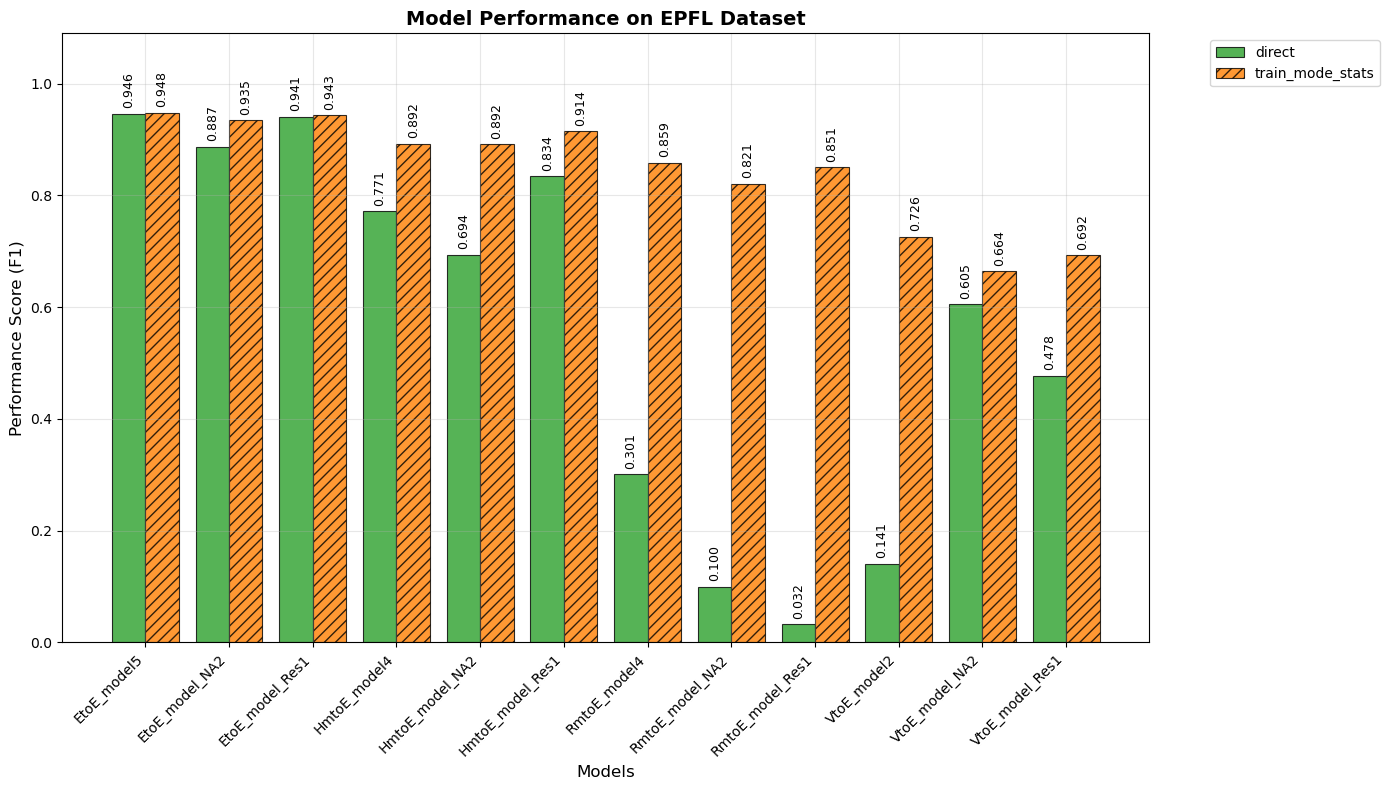

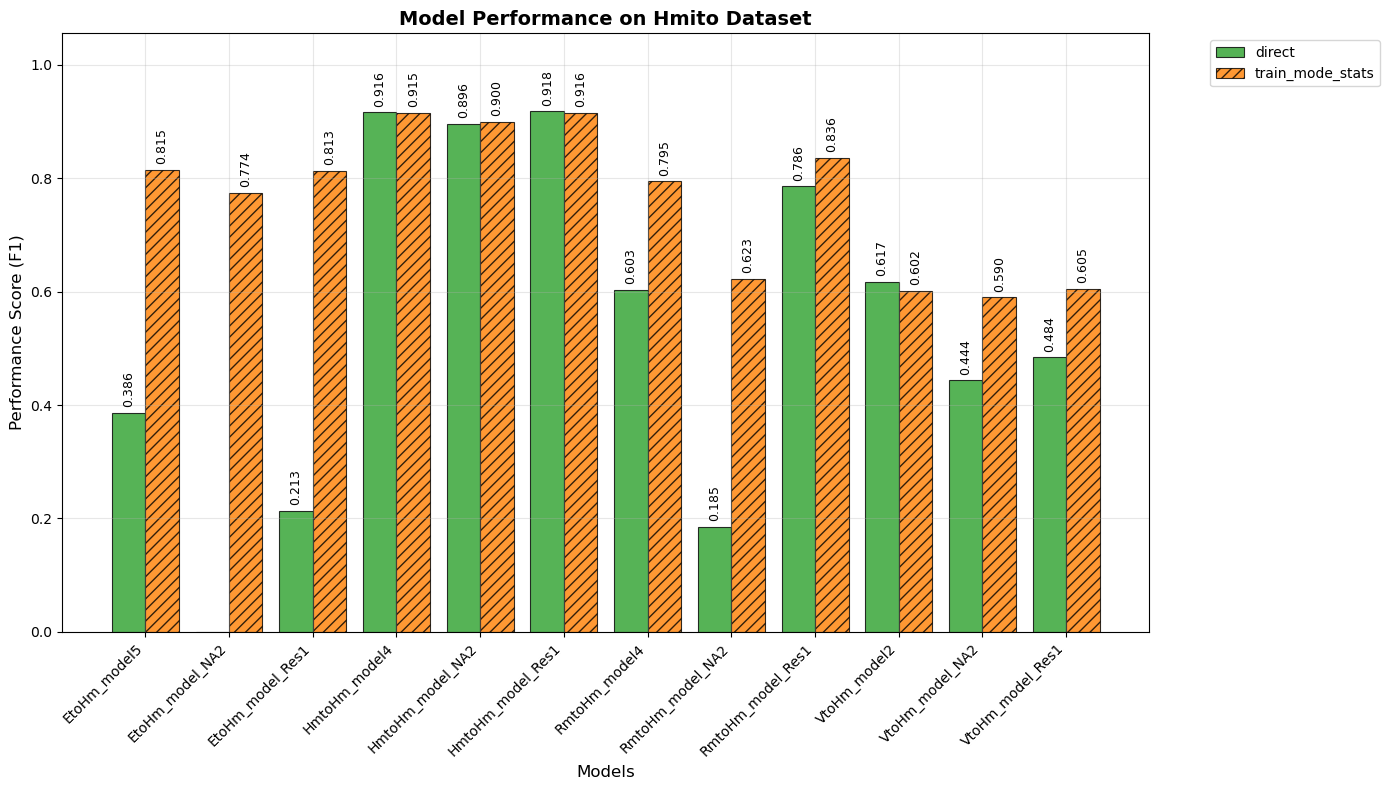

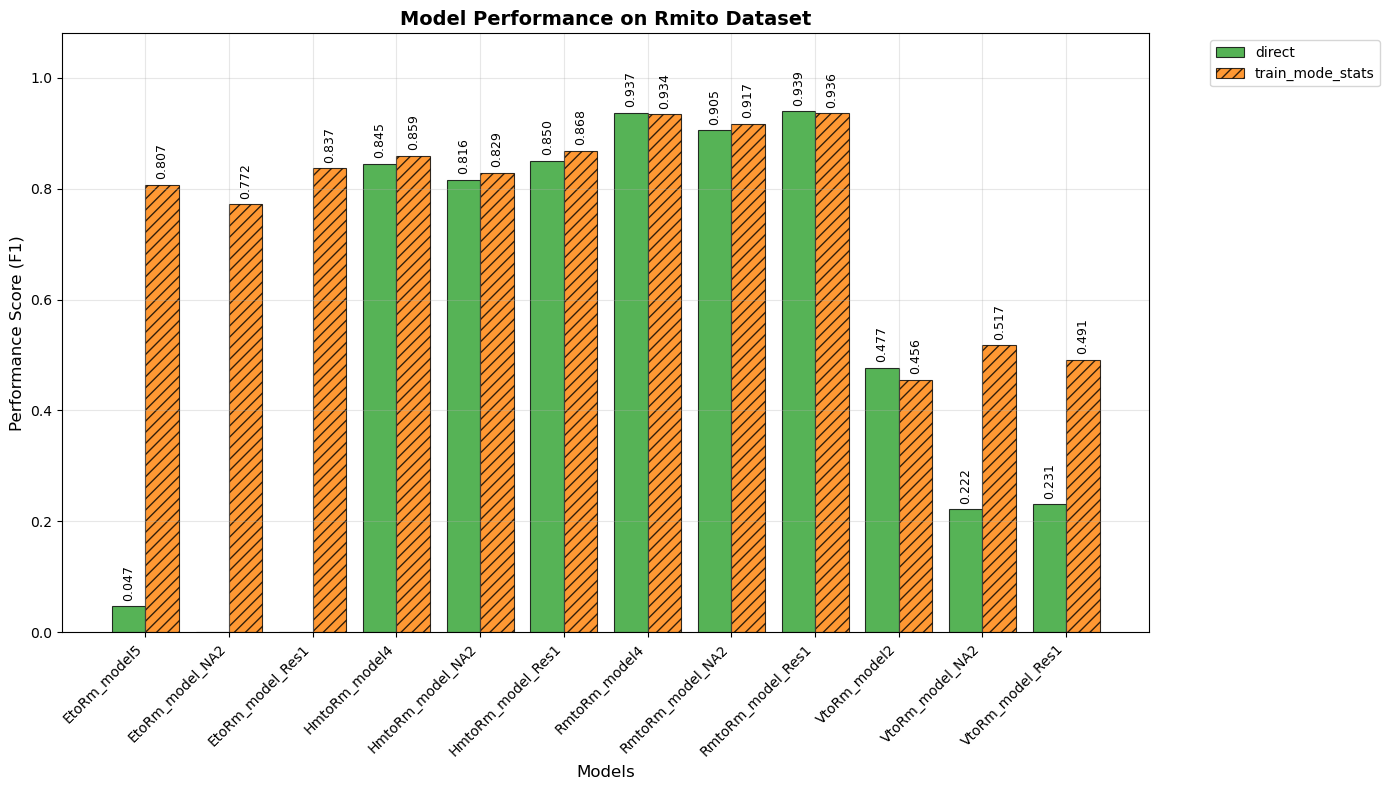

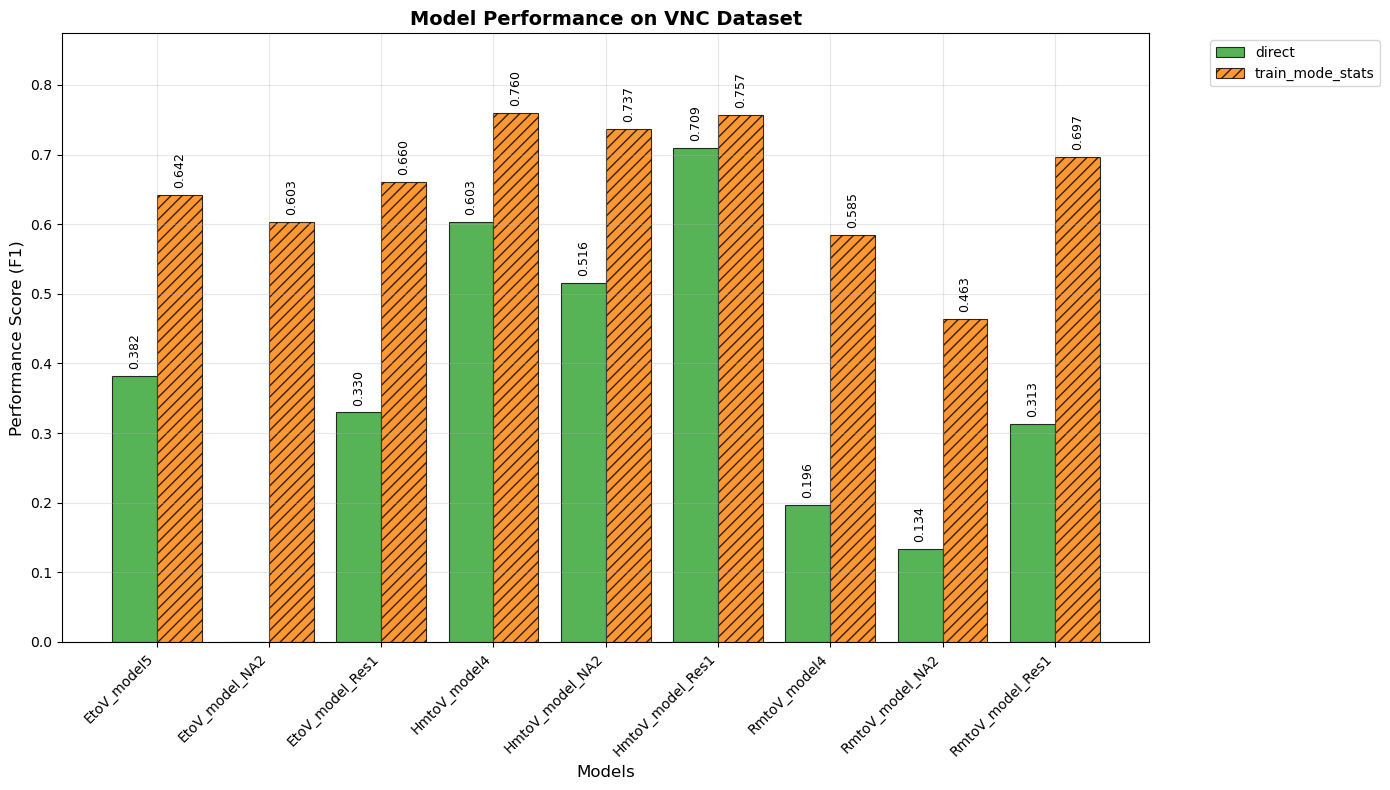

In [5]:
# Example usage - Plot each target in separate figures
print("Creating separate plots for each target...")
plot_model_performance_separate_figures(per_target_perf_results, save_plots=False)

In [ ]:
model_order = [
    "E_model5",
    "E_model_Res1",
    "E_model_NA2",
    "Hm_model_Res1",
    "Hm_model_NA2",
    "Hm_model4",
    "Rm_model_Res1",
    "Rm_model_NA2",
    "Rm_model4",
    "V_model2",
    "V_model_Res1",
    "V_model_NA2",
]

In [13]:
model_display_names = {
    "E_model5": "EPFL U-Net",
    "E_model_Res1": "EPFL ResUNet",
    "E_model_NA2": "EPFL U-Net (no augs)",
    "Hm_model_Res1": "Hmito ResUNet",
    "Hm_model_NA2": "Hmito U-Net (no augs)",
    "Hm_model4": "Hmito U-Net",
    "Rm_model_Res1": "Rmito ResUNet",
    "Rm_model_NA2": "Rmito U-Net (no augs)",
    "Rm_model4": "Rmito U-Net",
    "V_model2": "VNC U-Net",
    "V_model_Res1": "VNC ResUNet",
    "V_model_NA2": "VNC U-Net (no augs)",
}

Creating direct performance heatmap...


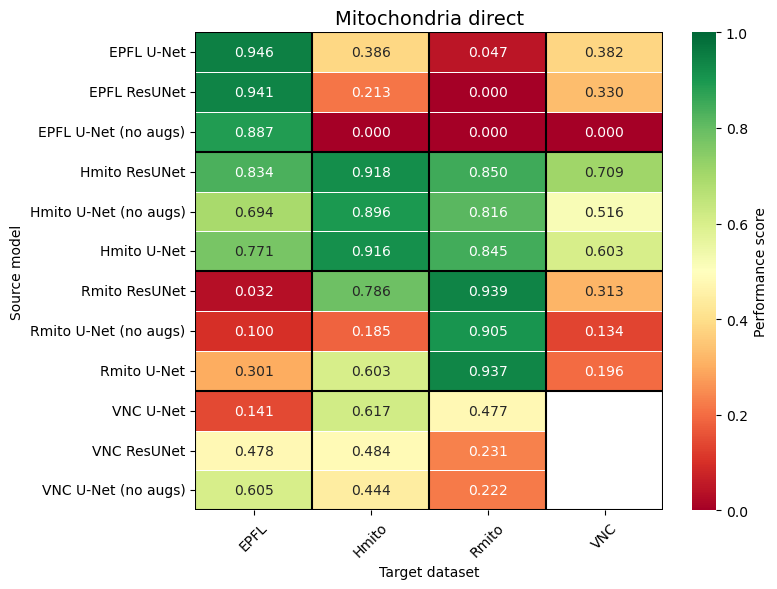

Creating train_mode_stats performance heatmap...


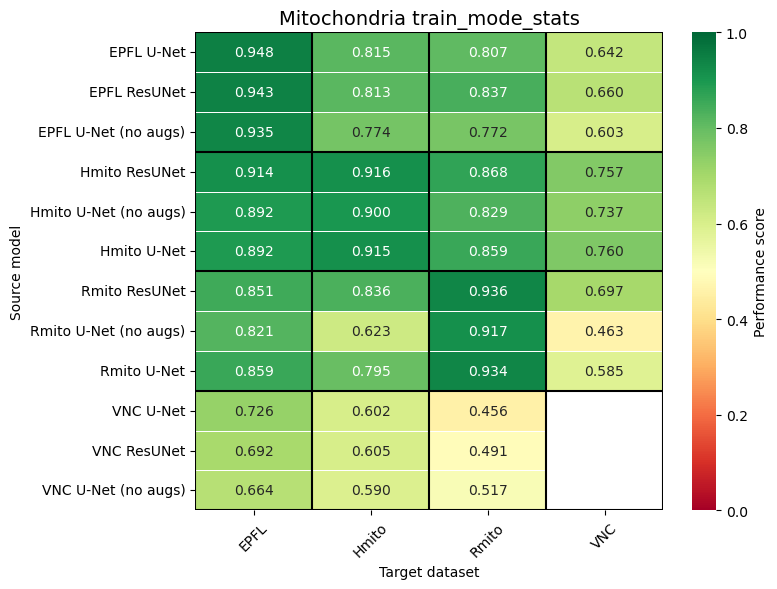

Creating difference heatmap (train_mode_stats - direct)...


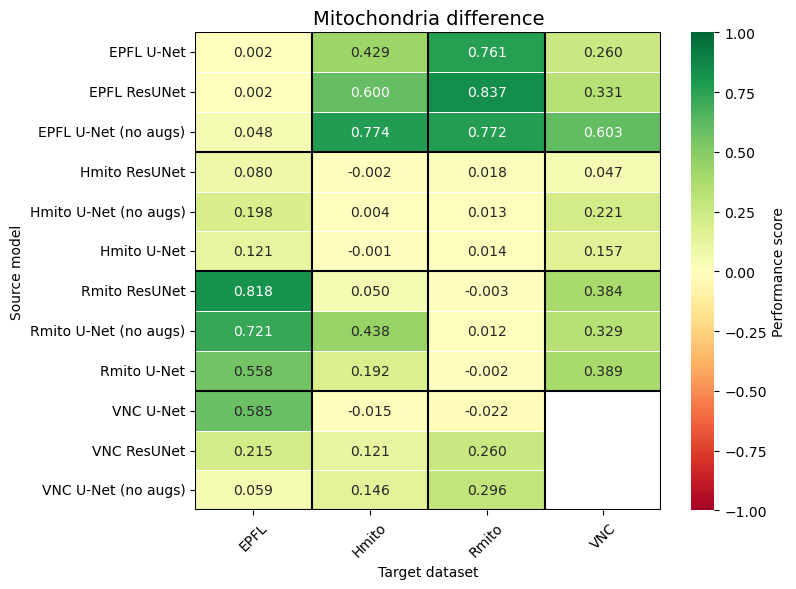

(<Figure size 800x600 with 2 Axes>,
 array([[<Axes: title={'center': 'Mitochondria difference'}, xlabel='Target dataset', ylabel='Source model'>]],
       dtype=object))

In [21]:
# Heatmap view across all targets and canonical source-model names
import importlib
import model_ranking.plots as plots

plots = importlib.reload(plots)

shared_figsize = (8, 6)

# Optional figure saving configuration
save_figures = True
save_dir = Path("/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures")
direct_save_path = str(save_dir / "mitochondria_direct_performance") if save_figures else None
adabn_save_path = str(save_dir / "mitochondria_adabn_performance") if save_figures else None
difference_save_path = str(save_dir / "mitochondria_adabn_minus_direct_performance") if save_figures else None

# Build an additional results dict with a derived 'difference' approach
per_target_perf_results_with_diff: Dict[str, Dict[str, Dict[str, float]]] = {}
for target, target_data in per_target_perf_results.items():
    per_target_perf_results_with_diff[target] = {}
    for transfer_model_name, score_dict in target_data.items():
        direct_score = score_dict.get("direct")
        adabn_score = score_dict.get("train_mode_stats")
        if direct_score is None or adabn_score is None:
            continue
        per_target_perf_results_with_diff[target][transfer_model_name] = {
            **score_dict,
            "difference": adabn_score - direct_score,
        }

print("Creating direct performance heatmap...")
plots.plot_performance_heatmaps_for_approaches(
    per_target_perf_results_with_diff,
    approaches=("direct",),
    model_order=model_order,
    model_display_names=model_display_names,
    source_block_size=3,
    cmap="RdYlGn",
    figsize=shared_figsize,
    save_path=direct_save_path,
    title_prefix="Mitochondria ",
)

print("Creating train_mode_stats performance heatmap...")
plots.plot_performance_heatmaps_for_approaches(
    per_target_perf_results_with_diff,
    approaches=("train_mode_stats",),
    model_order=model_order,
    model_display_names=model_display_names,
    source_block_size=3,
    cmap="RdYlGn",
    figsize=shared_figsize,
    save_path=adabn_save_path,
    title_prefix="Mitochondria ",
)

print("Creating difference heatmap (train_mode_stats - direct)...")
plots.plot_performance_heatmaps_for_approaches(
    per_target_perf_results_with_diff,
    approaches=("difference",),
    model_order=model_order,
    model_display_names=model_display_names,
    source_block_size=3,
    figsize=shared_figsize,
    cmap="RdYlGn",
    vmin=-1.0,
    vmax=1.0,
    save_path=difference_save_path,
    title_prefix="Mitochondria ",
)

model_ranking: /g/kreshuk/talks/model_ranking/src/model_ranking/__init__.py
plots: /g/kreshuk/talks/model_ranking/src/model_ranking/plots.py
signature: (per_target_perf_results: Dict[str, Dict[str, Dict[str, float]]], approaches: Sequence[str] = ('direct', 'train_mode_stats'), figsize: Tuple[int, int] = (16, 6), cmap: str = 'viridis', annot: bool = True, fmt: str = '.3f', save_path: Union[str, pathlib.Path, NoneType] = None, title_prefix: str = '') -> Tuple[Any, Any]
